# 导入依赖和数据

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder 

In [2]:
# 加载数据
train = pd.read_csv("train_new_features.csv")
test = pd.read_csv("test_new_features.csv")

y = train['Transported'].copy().astype(int)
X = train.drop('Transported', axis=1).copy()

# 合并测试集和训练集
data = pd.concat([X, test], axis=0).reset_index(drop=True)

# 缺失值分析

In [3]:
# 缺失值数量
print("\n缺失值数量")
print(data.isnull().sum())

# # 生成缺失值指示矩阵（1=缺失，0=存在）
# missing_indicator = data.isnull().astype(int)

# # 计算缺失值之间的相关性
# missing_corr = missing_indicator.corr()

# # 绘制热力图
# plt.figure(figsize=(15, 8))
# sns.heatmap(missing_corr, annot=True, cmap='coolwarm', fmt=".2f", 
#             mask=np.triu(np.ones_like(missing_corr, dtype=bool)))
# plt.title("Correlation Between Missing Values", fontsize=12)
# plt.show()


缺失值数量
PassengerId        0
HomePlanet       288
CryoSleep        310
Destination      274
Age              270
VIP              296
RoomService      263
FoodCourt        289
ShoppingMall     306
Spa              284
VRDeck           268
Name             294
exp_tol            0
No_spending        0
Group              0
Group_size         0
Solo               0
Cabin_deck       299
Cabin_number     299
Cabin_side       299
Cabin_region1      0
Cabin_region2      0
Cabin_region3      0
Cabin_region4      0
Cabin_region5      0
Cabin_region6      0
Cabin_region7      0
Surname          294
Family_Size      294
dtype: int64


发现缺失值相关性很弱

In [4]:
initial_count = len(data)
data_dropped = data.dropna()
remaining_ratio = len(data_dropped) / initial_count
print(f"移除所有缺失行后剩余数据比例: {remaining_ratio:.2%}")

移除所有缺失行后剩余数据比例: 76.23%


剩余数据量太少，不能删

## 缺失值处理


## HomePlanet缺失值处理

### 1.同一组的人来自同一颗星球

Text(0.5, 1.0, 'Number of unique planets per group')

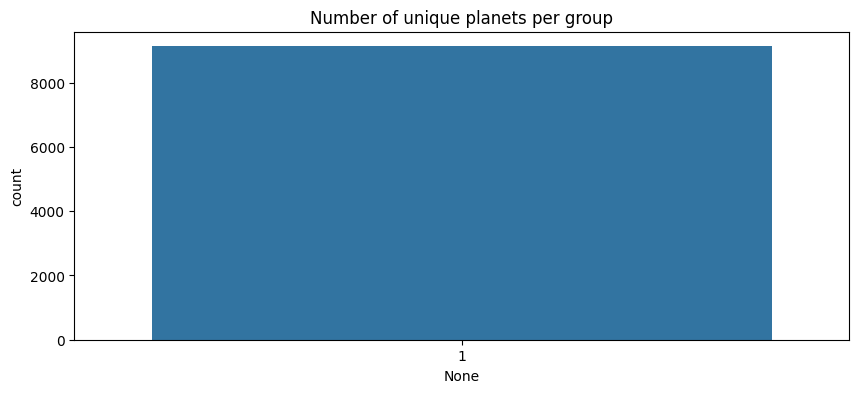

In [5]:
GHP_gb = data.groupby(['Group', 'HomePlanet'])['HomePlanet'].size().unstack().fillna(0)
GHP_gb.head()

plt.figure(figsize=(10, 4))
sns.countplot(x=(GHP_gb > 0).sum(axis=1))
plt.title('Number of unique planets per group')


只有1，说明同一组的乘客都来自同一星球。

In [6]:
#填充缺失值

HP_bef = data['HomePlanet'].isna().sum()

# 缺失星球值的乘客与已知星球值的乘客一组
GHP_index = data[data['HomePlanet'].isna()][(data[data['HomePlanet'].isna()]['Group']).isin(GHP_gb.index)].index

# 填充星球
data.loc[GHP_index, 'HomePlanet'] = data.iloc[GHP_index, :]['Group'].map(lambda x: GHP_gb.idxmax(axis=1)[x])

# 显示剩余缺失值
print('HomePlanet缺失值（处理前）:', HP_bef)
print('HomePlanet缺失值（处理后）:', data['HomePlanet'].isna().sum())





HomePlanet缺失值（处理前）: 288
HomePlanet缺失值（处理后）: 157


### 2. 家乡星球与甲板

<Axes: xlabel='HomePlanet', ylabel='Cabin_deck'>

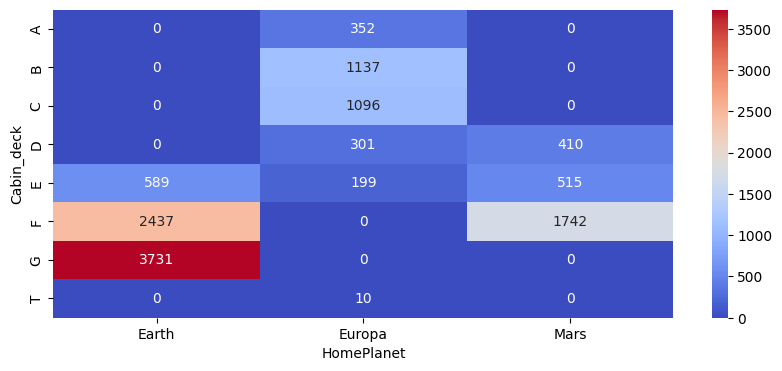

In [7]:
# CabinDeck 和 HomePlanet 的联合分布
CDHP_gb = data.groupby(['Cabin_deck', 'HomePlanet'])['HomePlanet'].size().unstack().fillna(0)
CDHP_gb.head()

# 查看关系
plt.figure(figsize=(10, 4))
sns.heatmap(CDHP_gb, annot=True, fmt='g', cmap='coolwarm')

可以看到：
A,B,C,T 层的乘客都来自欧罗巴
G 层乘客来自地球


In [8]:
# 处理前缺失值数量
HP_bef = data['HomePlanet'].isna().sum()

# A,B,C,T 层的乘客都来自欧罗巴
data.loc[(data['HomePlanet'].isna()) & (data['Cabin_deck'].isin(['A', 'B', 'C', 'T'])), 'HomePlanet'] = 'Europa'

# G 层乘客来自地球
data.loc[(data['HomePlanet'].isna()) & (data['Cabin_deck'] == 'G'), 'HomePlanet'] = 'Earth'

# 处理后缺失值数量
print('HomePlanet缺失值（处理前）:', HP_bef)
print('HomePlanet缺失值（处理后）:', data['HomePlanet'].isna().sum())

HomePlanet缺失值（处理前）: 157
HomePlanet缺失值（处理后）: 94


### 3. 家乡星球和家族名

Text(0.5, 1.0, 'Number of unique planets per surname')

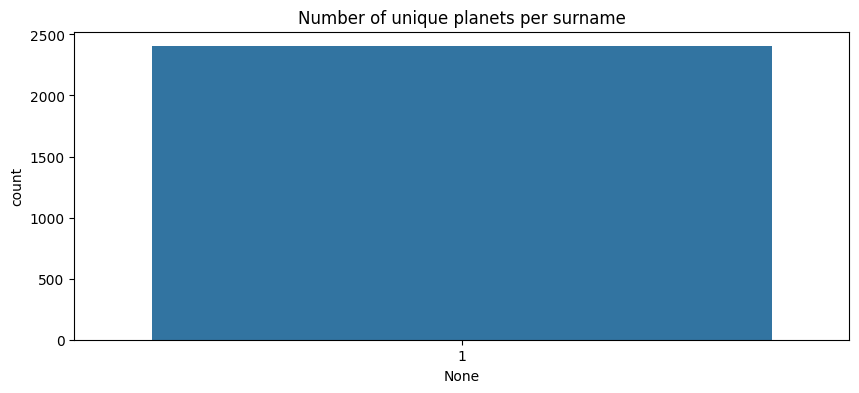

In [9]:
# 粗略观察下二者关系
SHP_gb = data.groupby(['Surname', 'HomePlanet'])['HomePlanet'].size().unstack().fillna(0)
SHP_gb.head()

# 统计每个姓氏中成员来自多少个的星球
plt.figure(figsize=(10, 4))
sns.countplot(x=(SHP_gb > 0).sum(axis=1))
plt.title('Number of unique planets per surname')

可以看到只有1。这说明同一姓氏的乘客都来自同一星球。

In [10]:
# 处理前的缺失值数量
HP_bef = data['HomePlanet'].isna().sum()

# 填充缺失值
SHP_index = data[data['HomePlanet'].isna()][(data[data['HomePlanet'].isna()]['Surname']).isin(SHP_gb.index)].index
data.loc[SHP_index, 'HomePlanet'] = data.iloc[SHP_index, :]['Surname'].map(lambda x: SHP_gb.idxmax(axis=1)[x])

# 处理后的缺失值数量
print('HomePlanet缺失值（处理前）:', HP_bef)
print('HomePlanet缺失值（处理后）:', data['HomePlanet'].isna().sum())

HomePlanet缺失值（处理前）: 94
HomePlanet缺失值（处理后）: 10


### 4.家乡星球与目的星球

<Axes: xlabel='HomePlanet', ylabel='Destination'>

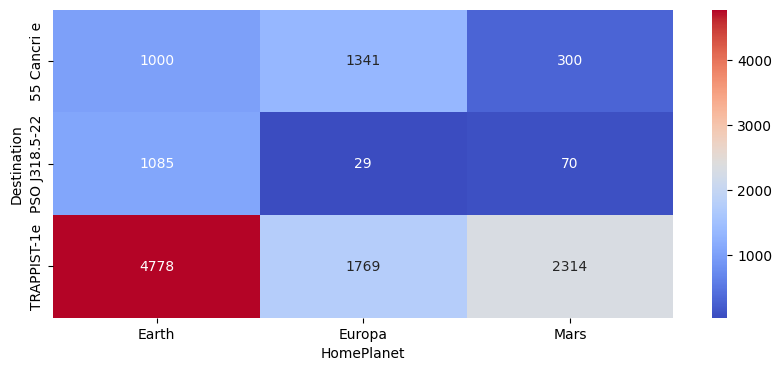

In [11]:
# 这两字段的联合分布
HPD_gb = data.groupby(['HomePlanet', 'Destination'])['Destination'].size().unstack().fillna(0)

# 热力图
plt.figure(figsize=(10, 4))
sns.heatmap(HPD_gb.T, annot=True, fmt='g', cmap='coolwarm')

可以见得，大多数人都是去TRAPPIST-1e的。
结合上面对Cabin和家乡星球的分析，我们取众数填充缺失值。

In [12]:
# Missing values before
HP_bef = data['HomePlanet'].isna().sum()

# 非D层甲板的乘客大多来自地球
data.loc[(data['HomePlanet'].isna()) & ~(data['Cabin_deck'] == 'D'), 'HomePlanet'] = 'Earth'
#D层甲板乘客大多来自火星
data.loc[(data['HomePlanet'].isna()) & (data['Cabin_deck'] == 'D'), 'HomePlanet'] = 'Mars'

# Print number of missing values left
print('#HomePlanet missing values before:', HP_bef)
print('#HomePlanet missing values after:', data['HomePlanet'].isna().sum())

#HomePlanet missing values before: 10
#HomePlanet missing values after: 0


至此，HomePlanet缺失值处理完毕。

## 目的字段缺失值处理

先看看有多少缺失值

In [13]:
data['Destination'].isna().sum()

274

<Axes: xlabel='Cabin_deck', ylabel='Destination'>

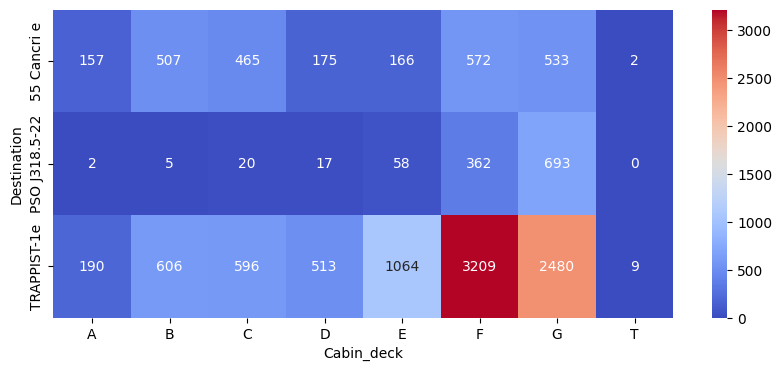

In [14]:
CDD_gb = data.groupby(['Cabin_deck', 'Destination'])['Destination'].size().unstack().fillna(0)

# Heatmap of missing values
plt.figure(figsize=(10, 4))
sns.heatmap(CDD_gb.T, annot=True, fmt='g', cmap='coolwarm')

经过比较，还是根据上面家乡星球和目的地的关系来填充缺失值。

In [15]:
# Missing values before
D_bef = data['Destination'].isna().sum()

# Fill missing Destination values with mode
data.loc[(data['Destination'].isna()), 'Destination'] = 'TRAPPIST-1e'

# Print number of missing values left
print('#Destination missing values before:', D_bef)
print('#Destination missing values after:', data['Destination'].isna().sum())

#Destination missing values before: 274
#Destination missing values after: 0


## 姓氏缺失值处理

Text(0.5, 1.0, 'Number of unique surnames by group')

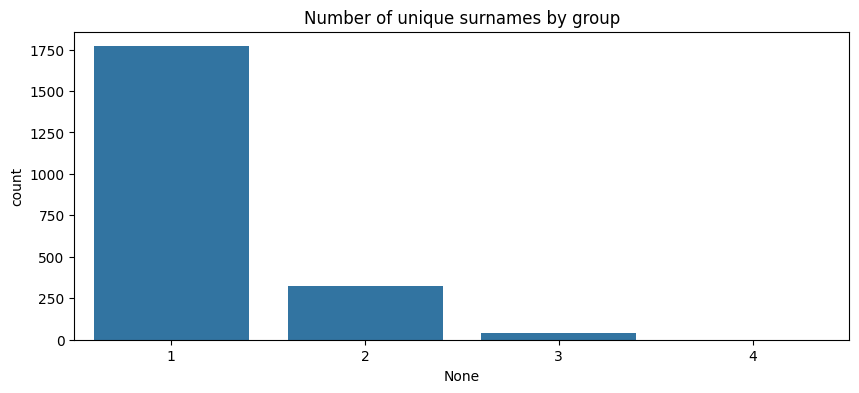

In [16]:
GSN_gb = data[data['Group_size'] > 1].groupby(['Group', 'Surname'])['Surname'].size().unstack().fillna(0)
GSN_gb.head()

# Countplot of unique values
plt.figure(figsize=(10, 4))
sns.countplot(x=(GSN_gb > 0).sum(axis=1))
plt.title('Number of unique surnames by group')

大多数组的乘客的姓氏都一样。据此填充姓氏的额缺失值。

In [17]:
# Missing values before
SN_bef = data['Surname'].isna().sum()

# Passengers with missing Surname and in a group with known majority Surname
GSN_index = data[data['Surname'].isna()][(data[data['Surname'].isna()]['Group']).isin(GSN_gb.index)].index

# Fill corresponding missing values
data.loc[GSN_index, 'Surname'] = data.iloc[GSN_index, :]['Group'].map(lambda x: GSN_gb.idxmax(axis=1)[x])

# Print number of missing values left
print('#Surname missing values before:', SN_bef)
print('#Surname missing values after:', data['Surname'].isna().sum())

#Surname missing values before: 294
#Surname missing values after: 155


删除或填充unknown

我们之所以要填补缺失的姓氏，是因为我们稍后将使用姓氏来填补其他特征的缺失值。 这也意味着我们可以提高家庭规模特征的准确性。

In [18]:
# Replace NaN's with outliers (so we can use map)
data['Surname'] = data['Surname'].fillna('Unknown')

# Update family size feature
data['Family_Size'] = data['Surname'].map(lambda x: data['Surname'].value_counts()[x])

# Put NaN's back in place of outliers
data.loc[data['Surname'] == 'Unknown', 'Surname'] = np.nan

# Say unknown surname means no family
data.loc[data['Family_Size'] > 100, 'Family_Size'] = 0

## 舱室缺失值处理

### 1.舱室与组（并填充舷侧）

同一组的人可能都在一个舱室里。

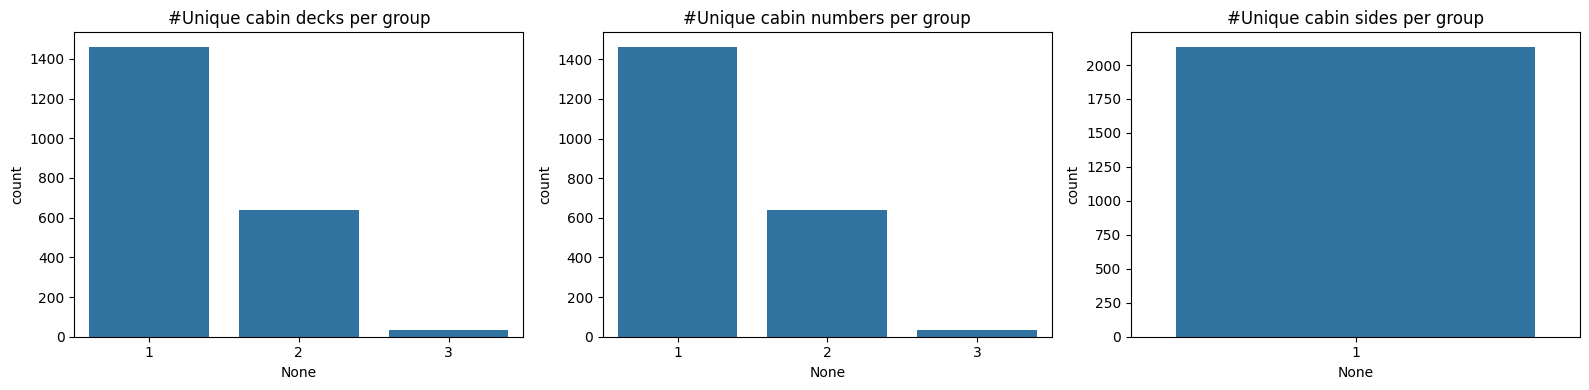

In [19]:
# Joint distribution of Group and Cabin features
GCD_gb = data[data['Group_size'] > 1].groupby(['Group', 'Cabin_deck'])['Cabin_deck'].size().unstack().fillna(0)
GCN_gb = data[data['Group_size'] > 1].groupby(['Group', 'Cabin_number'])['Cabin_number'].size().unstack().fillna(0)
GCS_gb = data[data['Group_size'] > 1].groupby(['Group', 'Cabin_side'])['Cabin_side'].size().unstack().fillna(0)

# Countplots
fig = plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
sns.countplot(x=(GCD_gb > 0).sum(axis=1))
plt.title('#Unique cabin decks per group')

plt.subplot(1, 3, 2)
sns.countplot(x=(GCN_gb > 0).sum(axis=1))
plt.title('#Unique cabin numbers per group')

plt.subplot(1, 3, 3)
sns.countplot(x=(GCS_gb > 0).sum(axis=1))
plt.title('#Unique cabin sides per group')
fig.tight_layout()

同一组的人都在同一侧。大多数同一组的乘客都在同一个舱室里。

In [20]:
# Missing values before
CS_bef = data['Cabin_side'].isna().sum()
# 填充缺失值
# Passengers with missing Cabin side and in a group with known Cabin side
GCS_index = data[data['Cabin_side'].isna()][(data[data['Cabin_side'].isna()]['Group']).isin(GCS_gb.index)].index

# Fill corresponding missing values
data.loc[GCS_index, 'Cabin_side'] = data.iloc[GCS_index, :]['Group'].map(lambda x: GCS_gb.idxmax(axis=1)[x])

# Print number of missing values left
print('#Cabin_side missing values before:', CS_bef)
print('#Cabin_side missing values after:', data['Cabin_side'].isna().sum())

#Cabin_side missing values before: 299
#Cabin_side missing values after: 162


### 2.舱室与姓氏（并填充舷侧）

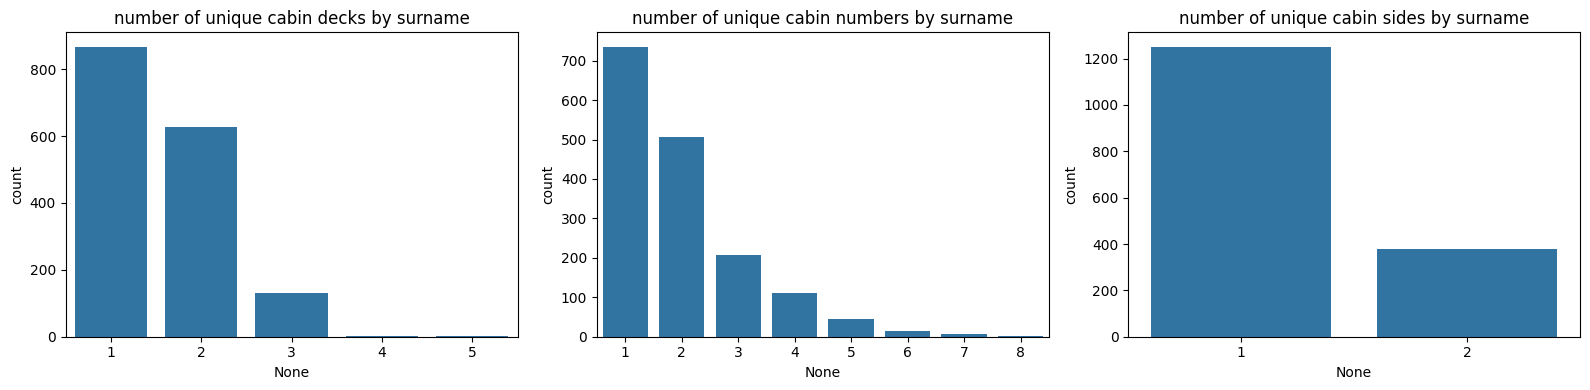

In [21]:
SCD_gb = data[data['Group_size'] > 1].groupby(['Surname', 'Cabin_deck'])['Cabin_deck'].size().unstack().fillna(0)
SCN_gb = data[data['Group_size'] > 1].groupby(['Surname', 'Cabin_number'])['Cabin_number'].size().unstack().fillna(0)
SCS_gb = data[data['Group_size'] > 1].groupby(['Surname', 'Cabin_side'])['Cabin_side'].size().unstack().fillna(0)

fig = plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
sns.countplot(x=(SCD_gb > 0).sum(axis=1))
plt.title('number of unique cabin decks by surname')

plt.subplot(1, 3, 2)
sns.countplot(x=(SCN_gb > 0).sum(axis=1))
plt.title('number of unique cabin numbers by surname')

plt.subplot(1, 3, 3)
sns.countplot(x=(SCS_gb > 0).sum(axis=1))
plt.title('number of unique cabin sides by surname')

fig.tight_layout()

又可以发现，同一家族的人一般都在同一侧

In [22]:
# Missing values before
CS_bef = data['Cabin_side'].isna().sum()

# Passengers with missing Cabin side and in a family with known Cabin side
SCS_index = data[data['Cabin_side'].isna()][(data[data['Cabin_side'].isna()]['Surname']).isin(SCS_gb.index)].index

# Fill corresponding missing values
data.loc[SCS_index, 'Cabin_side'] = data.iloc[SCS_index, :]['Surname'].map(lambda x: SCS_gb.idxmax(axis=1)[x])

# Print number of missing values left
print('#Cabin_side missing values before:', CS_bef)
print('#Cabin_side missing values after:', data['Cabin_side'].isna().sum())

#Cabin_side missing values before: 162
#Cabin_side missing values after: 66


### 3.填充完舷侧字段的缺失值

舷侧字段还有缺失值，采用众数填充。

In [23]:
# Value counts
data['Cabin_side'].value_counts()

Cabin_side
S    6504
P    6400
Name: count, dtype: int64

In [24]:
# Missing values before
CS_bef = data['Cabin_side'].isna().sum()

# Fill remaining missing values with outlier
data.loc[data['Cabin_side'].isna(), 'Cabin_side'] = 'Z'

# Print number of missing values left
print('#Cabin_side missing values before:', CS_bef)
print('#Cabin_side missing values after:', data['Cabin_side'].isna().sum())

#Cabin_side missing values before: 66
#Cabin_side missing values after: 0


### 4.填充甲板缺失值

#### 依据组别

从上面得到的频数图可知，同一组的人大概率在同一侧

In [25]:
# Missing values before
CD_bef = data['Cabin_deck'].isna().sum()

# Passengers with missing Cabin deck and in a group with known majority Cabin deck
GCD_index = data[data['Cabin_deck'].isna()][(data[data['Cabin_deck'].isna()]['Group']).isin(GCD_gb.index)].index

# Fill corresponding missing values
data.loc[GCD_index, 'Cabin_deck'] = data.iloc[GCD_index, :]['Group'].map(lambda x: GCD_gb.idxmax(axis=1)[x])

# Print number of missing values left
print('#Cabin_deck missing values before:', CD_bef)
print('#Cabin_deck missing values after:', data['Cabin_deck'].isna().sum())

#Cabin_deck missing values before: 299
#Cabin_deck missing values after: 162


#### 依据家乡星球、目的地、是否单人

In [26]:
# 联合分布
data.groupby(['HomePlanet', 'Destination', 'Solo', 'Cabin_deck'])['Cabin_deck'].size().unstack().fillna(0)

Cabin_deck                         A      B      C      D      E       F  \
HomePlanet Destination   Solo                                              
Earth      55 Cancri e   0       0.0    0.0    0.0    0.0   20.0    90.0   
                         1       0.0    0.0    0.0    0.0   47.0   289.0   
           PSO J318.5-22 0       0.0    0.0    0.0    0.0   18.0    67.0   
                         1       0.0    0.0    0.0    0.0   25.0   262.0   
           TRAPPIST-1e   0       0.0    0.0    0.0    0.0  133.0   438.0   
                         1       0.0    0.0    0.0    0.0  358.0  1350.0   
Europa     55 Cancri e   0      96.0  377.0  313.0   59.0   35.0     0.0   
                         1      67.0  141.0  159.0   46.0   34.0     0.0   
           PSO J318.5-22 0       2.0    5.0   11.0    0.0    0.0     0.0   
                         1       0.0    0.0   10.0    0.0    0.0     0.0   
           TRAPPIST-1e   0     152.0  459.0  428.0  120.0   53.0     0.0   
                         1      44.0  179.0  201.0   84.0   82.0     0.0   
Mars       55 Cancri e   0       0.0    0.0    0.0   32.0   15.0   104.0   
                         1       0.0    0.0    0.0   40.0   16.0    92.0   
           PSO J318.5-22 0       0.0    0.0    0.0    8.0    9.0    14.0   
                         1       0.0    0.0    0.0    9.0    7.0    21.0   
           TRAPPIST-1e   0       0.0    0.0    0.0  168.0  219.0   798.0   
                         1       0.0    0.0    0.0  164.0  263.0   743.0   

Cabin_deck                          G    T  
HomePlanet Destination   Solo               
Earth      55 Cancri e   0      272.0  0.0  
                         1      269.0  0.0  
           PSO J318.5-22 0      230.0  0.0  
                         1      466.0  0.0  
           TRAPPIST-1e   0     1075.0  0.0  
                         1     1509.0  0.0  
Europa     55 Cancri e   0        0.0  2.0  
                         1        0.0  0.0  
           PSO J318.5-22 0        0.0  0.0  
                         1        0.0  0.0  
           TRAPPIST-1e   0        0.0  1.0  
                         1        0.0  8.0  
Mars       55 Cancri e   0        0.0  0.0  
                         1        0.0  0.0  
           PSO J318.5-22 0        0.0  0.0  
                         1        0.0  0.0  
           TRAPPIST-1e   0        0.0  0.0  
                         1        0.0  0.0

*注：
* 来自火星的乘客最有可能在 F 层。
* 如果是单独旅行，来自欧罗巴的乘客（或多或少）最有可能在 C 层，否则在 B 层。
* 来自地球的乘客（或多或少）最有可能在 G 层。

In [27]:
# Missing values before
CD_bef = data['Cabin_deck'].isna().sum()

# Fill missing values using the mode
na_rows_CD = data.loc[data['Cabin_deck'].isna(), 'Cabin_deck'].index
data.loc[data['Cabin_deck'].isna(), 'Cabin_deck'] = \
    data.groupby(['HomePlanet', 'Destination', 'Solo'])['Cabin_deck'].transform(
        lambda x: x.fillna(pd.Series.mode(x)[0]))[
        na_rows_CD]

# Print number of missing values left
print('#Cabin_deck missing values before:', CD_bef)
print('#Cabin_deck missing values after:', data['Cabin_deck'].isna().sum())

#Cabin_deck missing values before: 162
#Cabin_deck missing values after: 0


### 5.填充舱室序号的缺失值

舱室号最可能与分组有关。使用散点图来考察两者间的关系

Text(0.5, 1.0, 'Cabin_number vs group ')

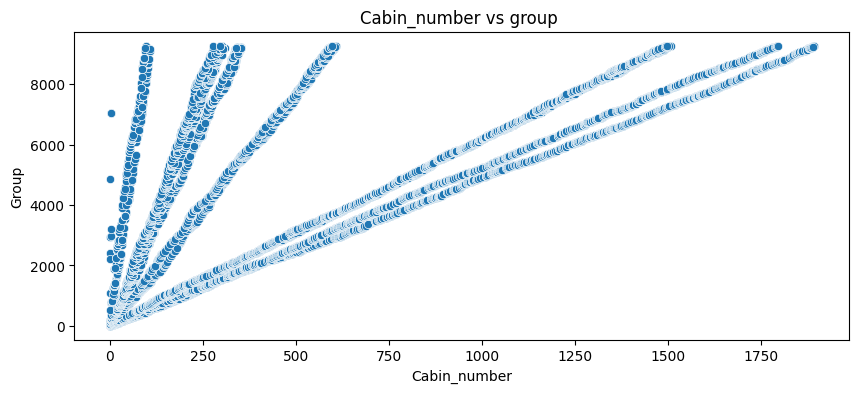

In [28]:
plt.figure(figsize=(10, 4))
sns.scatterplot(x=data['Cabin_number'], y=data['Group'])
plt.title('Cabin_number vs group ')

发现分组编号与舱室序号竟然呈现线性关系。图中点大约被划分8条直线，而船上正好有8层甲板，也许舱室序号还与甲板有关。
为了探究这层关系，可以在上图的基础上根据所在甲板对点进行着色。

Text(0.5, 1.0, 'Cabin_number vs group coloured by group')

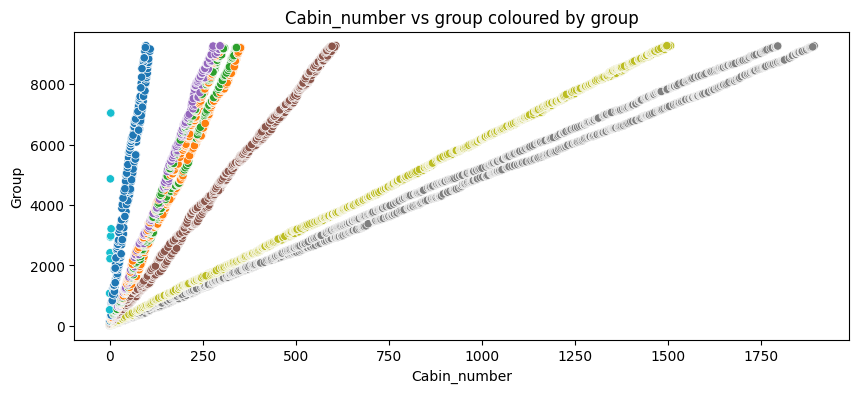

In [29]:
# Scatterplot
plt.figure(figsize=(10, 4))
sns.scatterplot(x=data['Cabin_number'], y=data['Group'],
                c=LabelEncoder().fit_transform(data.loc[~data['Cabin_number'].isna(), 'Cabin_deck']), cmap='tab10')
plt.title('Cabin_number vs group coloured by group')

正如所料。接下来，分批对同层甲板的舱室序号和组号进行线性回归。然后根据模型填充缺失值。

In [30]:
# Missing values before
CN_bef = data['Cabin_number'].isna().sum()

# Extrapolate linear relationship on a deck by deck basis
for deck in ['A', 'B', 'C', 'D', 'E', 'F', 'G']:
    # Features and labels
    X_CN = data.loc[~(data['Cabin_number'].isna()) & (data['Cabin_deck'] == deck), 'Group']
    y_CN = data.loc[~(data['Cabin_number'].isna()) & (data['Cabin_deck'] == deck), 'Cabin_number']
    X_test_CN = data.loc[(data['Cabin_number'].isna()) & (data['Cabin_deck'] == deck), 'Group']

    # Linear regression
    model_CN = LinearRegression()
    model_CN.fit(X_CN.values.reshape(-1, 1), y_CN)
    preds_CN = model_CN.predict(X_test_CN.values.reshape(-1, 1))

    # Fill missing values with predictions
    data.loc[(data['Cabin_number'].isna()) & (data['Cabin_deck'] == deck), 'Cabin_number'] = preds_CN.astype(int)

# Print number of missing values left
print('#Cabin_number missing values before:', CN_bef)
print('#Cabin_number missing values after:', data['Cabin_number'].isna().sum())

#Cabin_number missing values before: 299
#Cabin_number missing values after: 0


在特征工程中没有对舱室序号进行分箱，所以下面的代码不运行。

In [31]:
# One-hot encode cabin regions
# data['Cabin_region1']=(data['Cabin_number']<300).astype(int)
# data['Cabin_region2']=((data['Cabin_number']>=300) & (data['Cabin_number']<600)).astype(int)
# data['Cabin_region3']=((data['Cabin_number']>=600) & (data['Cabin_number']<900)).astype(int)
# data['Cabin_region4']=((data['Cabin_number']>=900) & (data['Cabin_number']<1200)).astype(int)
# data['Cabin_region5']=((data['Cabin_number']>=1200) & (data['Cabin_number']<1500)).astype(int)
# data['Cabin_region6']=((data['Cabin_number']>=1500) & (data['Cabin_number']<1800)).astype(int)
# data['Cabin_region7']=(data['Cabin_number']>=1800).astype(int)

## VIP缺失值处理

直接填充众数即可，因为只有少数人是VIP。

In [32]:
# Missing values before
V_bef = data['VIP'].isna().sum()

# Fill missing values with mode
data.loc[data['VIP'].isna(), 'VIP'] = False

# Print number of missing values left
print('#VIP missing values before:', V_bef)
print('#VIP missing values after:', data['VIP'].isna().sum())

#VIP missing values before: 296
#VIP missing values after: 0


## 年龄缺失值处理

年龄在 HomePlanet、小组规模、支出和舱室甲板等许多特征上都存在差异，因此我们将根据这些分组的中位数来估算缺失值。

In [33]:
# Joint distribution
data.groupby(['HomePlanet', 'No_spending', 'Solo', 'Destination', 'Cabin_side', 'Cabin_deck'])[
    'Age'].median().unstack().fillna(0)

Cabin_deck                                              A    B    C     D  \
HomePlanet No_spending Solo Destination   Cabin_side                        
Earth      0           0    55 Cancri e   P           0.0  0.0  0.0   0.0   
                                          S           0.0  0.0  0.0   0.0   
                            PSO J318.5-22 P           0.0  0.0  0.0   0.0   
                                          S           0.0  0.0  0.0   0.0   
                            TRAPPIST-1e   P           0.0  0.0  0.0   0.0   
...                                                   ...  ...  ...   ...   
Mars       1           1    PSO J318.5-22 S           0.0  0.0  0.0   0.0   
                                          Z           0.0  0.0  0.0   0.0   
                            TRAPPIST-1e   P           0.0  0.0  0.0  34.0   
                                          S           0.0  0.0  0.0  34.5   
                                          Z           0.0  0.0  0.0   0.0   

Cabin_deck                                               E     F     G    T  
HomePlanet No_spending Solo Destination   Cabin_side                         
Earth      0           0    55 Cancri e   P           23.0  21.0  31.0  0.0  
                                          S           25.5  21.0  30.5  0.0  
                            PSO J318.5-22 P           25.0  22.5  26.0  0.0  
                                          S           28.0  24.0  32.0  0.0  
                            TRAPPIST-1e   P           25.0  25.0  26.0  0.0  
...                                                    ...   ...   ...  ...  
Mars       1           1    PSO J318.5-22 S           45.0  38.0   0.0  0.0  
                                          Z            0.0  41.0   0.0  0.0  
                            TRAPPIST-1e   P           26.0  29.0   0.0  0.0  
                                          S           30.5  29.5   0.0  0.0  
                                          Z            0.0  75.0   0.0  0.0  

[87 rows x 8 columns]

In [34]:
# Missing values before
A_bef = data['Age'].isna().sum()
A_bef

# Fill missing values using the median
na_rows_A = data.loc[data['Age'].isna(), 'Age'].index
# 把能想到的分类字段都填进去
data.loc[data['Age'].isna(), 'Age'] = \
    data.groupby(['HomePlanet', 'No_spending', 'Solo', 'Destination', 'Cabin_side', 'Cabin_deck'])['Age'].transform(
        lambda x: x.fillna(x.median()))[na_rows_A]

# Print number of missing values left
print('#Age missing values before:', A_bef)
print('#Age missing values after:', data['Age'].isna().sum())

#Age missing values before: 270
#Age missing values after: 0


## 花费缺失值处理

In [35]:
#查看冬眠与花费的关系
data.groupby(['No_spending', 'CryoSleep'])['CryoSleep'].size().unstack().fillna(0)


CryoSleep,False,True
No_spending,,
0,7339.0,0.0
1,740.0,4581.0


冬眠的乘客消费字段一律为0

In [36]:
exp_feats = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
E_bef = data[exp_feats].isna().sum().sum()

for col in exp_feats:
    data.loc[(data[col].isna()) & (data['CryoSleep'] == True), col] = 0

print('#Expenditure missing values before:', E_bef)
print('#Expenditure missing values after:', data[exp_feats].isna().sum().sum())

#Expenditure missing values before: 1410
#Expenditure missing values after: 879


对冬眠字段缺失的记录，如果它的总消费为0，则认为该乘客冬眠。

In [37]:
# Missing values before
CSL_bef = data['CryoSleep'].isna().sum()

# Fill missing values using the mode


data.loc[data['CryoSleep'].isna() & data['No_spending'] == 0, 'CryoSleep'] = True
data.loc[data['CryoSleep'].isna() & data['No_spending'] == 1, 'CryoSleep'] = False

# Print number of missing values left
print('#CryoSleep missing values before:', CSL_bef)
print('#CryoSleep missing values after:', data['CryoSleep'].isna().sum())

#CryoSleep missing values before: 310
#CryoSleep missing values after: 0


对于剩下的消费字段，分组填充平均值

In [38]:
# Missing values before
E_bef = data[exp_feats].isna().sum().sum()

# Fill remaining missing values using the median
for col in exp_feats:
    na_rows = data.loc[data[col].isna(), col].index
    data.loc[data[col].isna(), col] = \
        data.groupby(['HomePlanet', 'VIP', 'Solo', 'Age'])[col].transform(lambda x: x.fillna(x.mean()))[na_rows]

# Print number of missing values left
print('#Expenditure missing values before:', E_bef)
print('#Expenditure missing values after:', data[exp_feats].isna().sum().sum())
data.loc[data[exp_feats].isna().any(axis=1)]

#Expenditure missing values before: 879
#Expenditure missing values after: 9


,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,...,Cabin_side,Cabin_region1,Cabin_region2,Cabin_region3,Cabin_region4,Cabin_region5,Cabin_region6,Cabin_region7,Surname,Family_Size
2137,2295_01,Earth,True,TRAPPIST-1e,75.0,False,0.0,0.0,1224.0,NaN,...,P,0,1,0,0,0,0,0,Emenez,15
2762,2970_01,Earth,True,TRAPPIST-1e,24.5,False,740.0,82.0,6.0,NaN,...,Z,0,0,0,0,0,0,0,Adkinson,4
3526,3784_01,Earth,True,TRAPPIST-1e,77.0,False,0.0,NaN,131.0,3981.0,...,P,0,0,1,0,0,0,0,Morrencis,8
5884,6234_01,Mars,True,PSO J318.5-22,40.0,True,301.0,0.0,1310.0,4.0,...,P,0,0,0,0,1,0,0,Bun,7
7568,8088_02,Mars,True,TRAPPIST-1e,23.0,True,3.0,0.0,0.0,1677.0,...,P,0,0,0,0,0,1,0,Kart,6
9081,0814_01,Mars,True,TRAPPIST-1e,22.0,True,2227.0,324.0,47.0,NaN,...,S,1,0,0,0,0,0,0,Cha,4
9431,1502_02,Europa,True,55 Cancri e,57.0,True,1.0,3637.0,0.0,3.0,...,P,1,0,0,0,0,0,0,Donotaked,6
10913,4802_02,Earth,True,PSO J318.5-22,74.0,False,568.0,17.0,0.0,NaN,...,P,0,0,1,0,0,0,0,Lambucketty,8
11484,6185_01,Europa,True,55 Cancri e,66.0,False,0.0,1029.0,NaN,1192.0,...,P,0,1,0,0,0,0,0,NaN,0


In [39]:
# Update expenditure and no_spending
data['Expenditure'] = data[exp_feats].sum(axis=1)
data['No_spending'] = (data['Expenditure'] == 0).astype(int)

# 存数据

In [40]:
data.isna().sum()

PassengerId        0
HomePlanet         0
CryoSleep          0
Destination        0
Age                0
VIP                0
RoomService        0
FoodCourt          1
ShoppingMall       1
Spa                4
VRDeck             3
Name             294
exp_tol            0
No_spending        0
Group              0
Group_size         0
Solo               0
Cabin_deck         0
Cabin_number       0
Cabin_side         0
Cabin_region1      0
Cabin_region2      0
Cabin_region3      0
Cabin_region4      0
Cabin_region5      0
Cabin_region6      0
Cabin_region7      0
Surname          155
Family_Size        0
Expenditure        0
dtype: int64

把不再需要的字段删掉，用中位数填充缺失值。

In [41]:
del data['Surname']
del data['Name']

In [ ]:
for exp in exp_feats:
    data[exp].fillna(data[exp].median(), inplace=True)

In [43]:
data.isna().sum()

PassengerId      0
HomePlanet       0
CryoSleep        0
Destination      0
Age              0
VIP              0
RoomService      0
FoodCourt        0
ShoppingMall     0
Spa              0
VRDeck           0
exp_tol          0
No_spending      0
Group            0
Group_size       0
Solo             0
Cabin_deck       0
Cabin_number     0
Cabin_side       0
Cabin_region1    0
Cabin_region2    0
Cabin_region3    0
Cabin_region4    0
Cabin_region5    0
Cabin_region6    0
Cabin_region7    0
Family_Size      0
Expenditure      0
dtype: int64

储存为文件

In [44]:
X = data[data['PassengerId'].isin(train['PassengerId'].values)].copy()
X_test = data[data['PassengerId'].isin(test['PassengerId'].values)].copy()

X.to_csv('train_clean.csv', index=False)
X_test.to_csv('test_clean.csv', index=False)